# Load models and media and compare growth

In [197]:

import os
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

import pandas as pd
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
import cobra
from collections import defaultdict
import numpy as np
from copy import deepcopy
#from upsetplot import UpSet, from_indicators, from_contents
from venn import venn
import math
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted, venn3
from functions import save_media, create_medium, get_exchanges, get_model_specific_medium, assign_metaboliteclass_medium

In [2]:
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/add_exr/"
media_save_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"

In [208]:
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [4]:
# Load and store all media 
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"))
AF8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_AF_mock.csv"))
Root7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_Root_media_liquidphase.csv"))
Root8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_Root_media_liquidphase.csv"))
TSB = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/TSB_medium.csv", header=None)

#### Functions

In [26]:
def assign_metaboliteclass_medium(medium, met_class_dict):
    medium_met_class = defaultdict(list)
    count_dict = defaultdict(int)
    for ex_r in medium.keys():
        if ex_r in met_class_dict.keys():
            mc = met_class_dict[ex_r]
            medium_met_class[mc].append(ex_r)
            count_dict[mc] += 1
        else:
            print(f"{ex_r} could not be found in metabolite lookup")
    return medium_met_class, count_dict

In [27]:
def save_media(medium_dict, medianame):
    medium_df = pd.DataFrame.from_dict(
        medium_dict, orient="index")
    filename = f"{medianame}.csv"
    filepath = os.path.join(media_save_dir, filename)
    medium_df.to_csv(filepath)    
    return medium_df

#### Create media from csv and compare growth on base media 

In [206]:
AF7 = create_medium(AF7)
AF8 = create_medium(AF8)
Root7 = create_medium(Root7)
Root8 = create_medium(Root8)
TSB = create_medium(TSB)

In [29]:
mediadict = {"AF7" : AF7, "AF8": AF8, "Root7": Root7, "Root8": Root8, "TSB": TSB}

In [30]:
compare_growth_media = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in mediadict.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            model.medium = medium_
            
            sol = model.slim_optimize()
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            model.medium = default_medium
            
    compare_growth_media[model_id] = cur_m

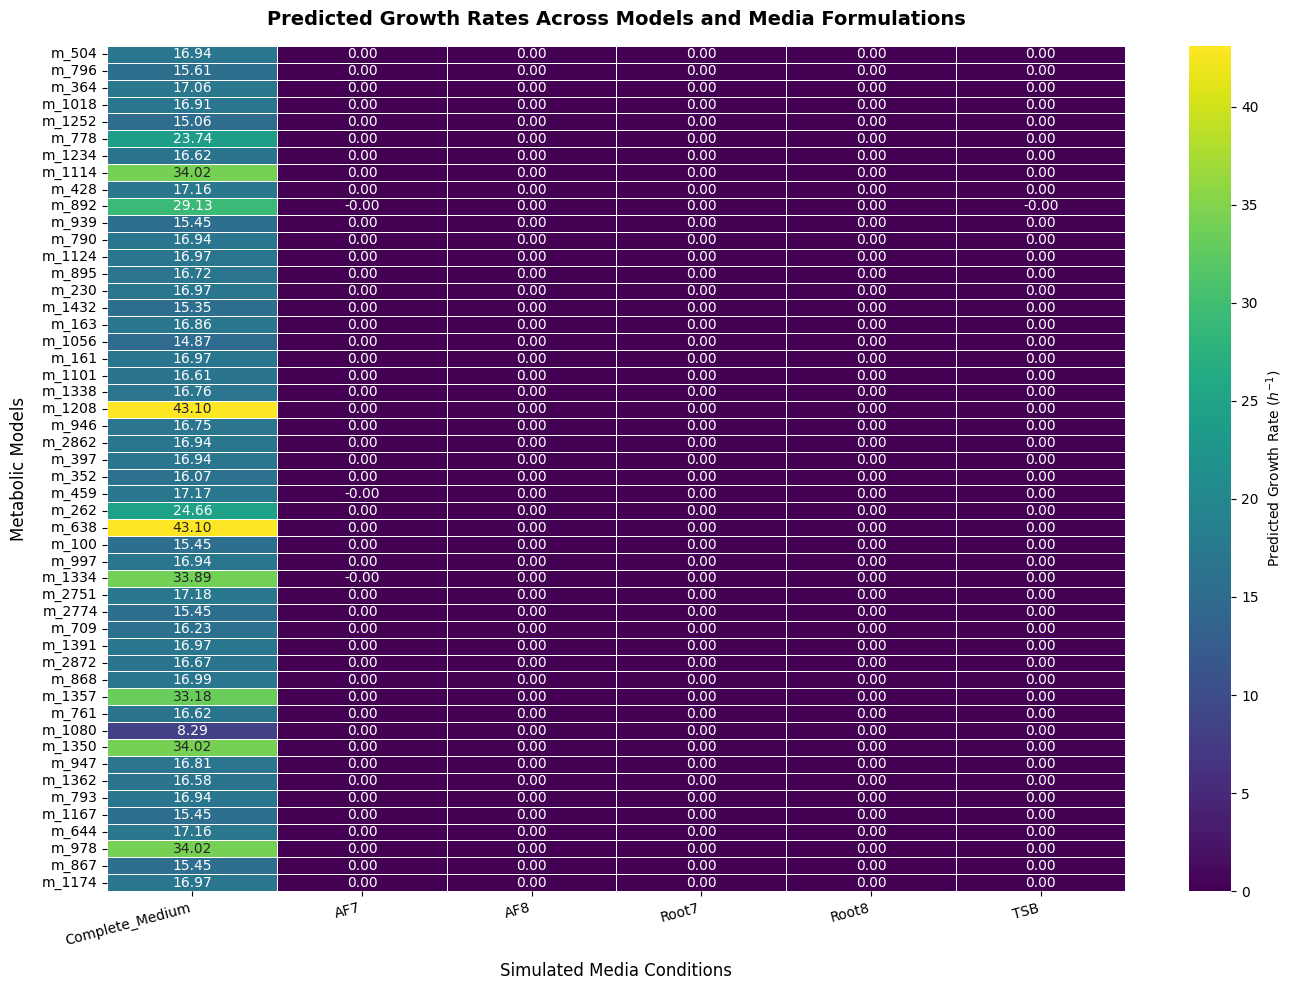

In [31]:
df_growthrate2medium = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media.items()
}).T

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_growthrate2medium, 
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Use COBRA minimal_medium to identify minimal medium: cobra.medium.minimal_medium.add_mip_obj

In [20]:
minimal_medium = {}
min_med_growth_rates = {}
for file in os.listdir(model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    #print(model_id)
    mini_med = cobra.medium.minimal_medium(model, 1.0, exports = True, minimize_components=True)
    minimal_medium[model_id] = mini_med

    if mini_med is not None:
        default_medium = model.medium.copy()
        try:
            model.medium = mini_med.to_dict() 
            growth_rate = model.slim_optimize()
            min_med_growth_rates[model_id] = growth_rate if not np.isnan(growth_rate) else 0.0
        except Exception as e:
            print(f"Error calculating growth on minimal medium for {model_id}: {e}")
            min_med_growth_rates[model_id] = 0.0
        finally:
            model.medium = default_medium  
    else:
        # If no minimal medium was found, growth rate is 0.0
        min_med_growth_rates[model_id] = 0.0

In [21]:
# list of all EX_reactions from minimal_media
count_mods_per_reaction = defaultdict(list)

for model_id, medium in minimal_medium.items():
    if medium is None:
        print(f"Skipping {model_id} because no minimal medium could be found.")
        continue
    for ex_r, flux in medium.items():
        if flux > 0:
            count_mods_per_reaction[ex_r].append(model_id)

In [22]:
# figure out which ex_r are missing in the predefined media
ex_r_missinginmedia = defaultdict(list)
for ex_r, counts in count_mods_per_reaction.items():
    if len(counts) >=1:
        for media_id, medium in mediadict.items():
            if ex_r not in medium.keys():
                ex_r_missinginmedia[ex_r].append(media_id)

In [23]:
# Find all reactions missing from the all media
reactions_missing_in_all_media = [
    ex_r for ex_r, media_list in ex_r_missinginmedia.items() if len(media_list) == 5
]

print(f"Reactions missing in all media and at least 5 models: {reactions_missing_in_all_media}")
print(f"Count: {len(reactions_missing_in_all_media)}")

Reactions missing in all media and at least 5 models: ['EX_3ump_e', 'EX_6pgc_e', 'EX_LalaDgluMdap_e', 'EX_R_3httdca_e', 'EX_acgam1p_e', 'EX_acnam_e', 'EX_ala_leu_e', 'EX_alaala_e', 'EX_amp_e', 'EX_bz_e', 'EX_cmp_e', 'EX_coa_e', 'EX_dtmp_e', 'EX_glyc3p_e', 'EX_gmp_e', 'EX_h2s_e', 'EX_nmn_e', 'EX_pheme_e', 'EX_pydxn_e', 'EX_sheme_e', 'EX_uaccg_e', 'EX_lysglugly_e', 'EX_pydam_e', 'EX_uri_e', 'EX_for_e', 'EX_g6p_e', 'EX_icit_e', 'EX_5mcsn_e', 'EX_acmana_e', 'EX_dhap_e', 'EX_g3pg_e', 'EX_gly_leu_e', 'EX_meoh_e', 'EX_orn_e', 'EX_pep_e', 'EX_prohisglu_e', 'EX_s_e', 'EX_mevR_e', 'EX_pydx_e', 'EX_5oxpro_e', 'EX_cytd_e', 'EX_glyglygln_e', 'EX_LalaDgluMdapDala_e', 'EX_acald_e', 'EX_alagly_e', 'EX_asp__D_e', 'EX_fe3pyovd_kt_e', 'EX_hcys__L_e', 'EX_mmet_e', 'EX_nac_e', 'EX_no3_e', 'EX_sbt__D_e', 'EX_udcpp_e', 'EX_ump_e', 'EX_3amp_e', 'EX_argp_e', 'EX_ch4s_e', 'EX_gsn_e', 'EX_tton_e', 'EX_galctn__D_e', 'EX_peng_e', 'EX_adn_e', 'EX_f6p_e', 'EX_indole_e', 'EX_so4_e', 'EX_ala_L_asp__L_e', 'EX_fald_e', 

In [24]:
missing_TSB = [reac_id for reac_id, media_ids in ex_r_missinginmedia.items() if "TSB" in media_ids]

#### complete media with minimal media results 

In [25]:
# add all missing reactions to the predef media and see how they grow
completed_media = {}
for medium_id, reactions in mediadict.items():
    medium_id_new = f"{medium_id}_completed"
    completed_media[medium_id_new] = deepcopy(reactions)

for ex_r in missing_TSB:
    #for medium_id in medium_ids:
    medium_id_new = medium_id + "_completed"
    completed_media[medium_id_new][ex_r] = 10.0


TSB_completed_micom = completed TSB medium for the communites and then these combined, see create_communities_andgetminimalmedia

In [40]:
TSB_completed_micom_e = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/Completed_TSB.csv")

In [41]:
TSB_completed_micom_e = create_medium(TSB_completed_micom_e)

In [43]:
TSB_completed_micom

{'EX_6pgc_m': 0.0033225782631612,
 'EX_LalaDgluMdap_m': 0.0073641944286015,
 'EX_R_3httdca_m': 0.0064722399115009,
 'EX_acmana_m': 0.0125403644216016,
 'EX_acnam_m': 0.0025138688763015,
 'EX_ala__L_m': 100.0,
 'EX_ala_leu_m': 0.0217159999731498,
 'EX_alaala_m': 0.0075340962310001,
 'EX_amp_m': 0.022420155557392,
 'EX_arg__L_m': 100.0,
 'EX_asn__L_m': 100.0,
 'EX_bz_m': 1.5774514294964897e-05,
 'EX_ca2_m': 10.0,
 'EX_cl_m': 10.0,
 'EX_cmp_m': 0.0180652679326324,
 'EX_cobalt2_m': 10.0,
 'EX_cu2_m': 10.0,
 'EX_cys__L_m': 100.0,
 'EX_dtmp_m': 0.0042281967649666,
 'EX_fe2_m': 10.0,
 'EX_fol_m': 10.0,
 'EX_g3pg_m': 0.0023672140705601,
 'EX_gln__L_m': 100.0,
 'EX_glu__L_m': 100.0,
 'EX_gly_m': 100.0,
 'EX_glyc3p_m': 0.0106857339243066,
 'EX_gmp_m': 0.0240268835111571,
 'EX_h2_m': 1000.0,
 'EX_h2o_m': 1000.0,
 'EX_h_m': 1000.0,
 'EX_hdca_m': 10.0,
 'EX_his__L_m': 100.0,
 'EX_ile__L_m': 100.0,
 'EX_k_m': 10.0,
 'EX_lys__L_m': 100.0,
 'EX_meoh_m': 1.0,
 'EX_met__L_m': 100.0,
 'EX_mevR_m': 6.0607

In [44]:
# need to rename _m to _e
TSB_completed_micom = {
    key.replace("_m", "_e"): value for key, value in TSB_completed_micom_e.items()
}


In [45]:
# media of interest 
target_media = { }
target_media["TSB_community_complete"] = TSB_completed_micom
target_media["TSB_minimed"] = completed_media["TSB_completed"]

In [49]:
compare_growth_media_complete = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in target_media.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            
            # --- FIX 1: Sanitize the incoming medium dictionary ---
            # Remove any keys that have nan values before applying to the model
            clean_medium = {
                rxn_id: val for rxn_id, val in medium_.items() 
                if not (isinstance(val, float) and math.isnan(val))
            }
            
            model.medium = clean_medium
            print(model.medium)
            sol = model.slim_optimize()
            if math.isnan(sol):
                sol = 0.0
                
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            # --- FIX 2: Safeguard the reset ---
            # Reset to default medium
            model.medium = default_medium
            
    compare_growth_media_complete[model_id] = cur_m

{'EX_3ump_e': 0.001789457234357, 'EX_6pgc_e': 0.0033225782631612, 'EX_LalaDgluMdap_e': 0.0073641944286015, 'EX_R_3httdca_e': 0.0064722399115009, 'EX_acgam1p_e': 0.0038655958373575, 'EX_acnam_e': 0.0025138688763015, 'EX_ala_leu_e': 0.0217159999731498, 'EX_alaala_e': 0.0075340962310001, 'EX_amp_e': 0.022420155557392, 'EX_arg__L_e': 100.0, 'EX_bz_e': 1.5774514294964897e-05, 'EX_ca2_e': 10.0, 'EX_cl_e': 10.0, 'EX_cmp_e': 0.0180652679326324, 'EX_coa_e': 9.307656258577906e-05, 'EX_cobalt2_e': 10.0, 'EX_cu2_e': 10.0, 'EX_dtmp_e': 0.0042281967649666, 'EX_fe2_e': 10.0, 'EX_fol_e': 10.0, 'EX_gln__L_e': 100.0, 'EX_gly_asn__L_e': 100.0, 'EX_glyc3p_e': 0.0106857339243066, 'EX_gmp_e': 0.0240268835111571, 'EX_h2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_h_e': 1000.0, 'EX_hdca_e': 10.0, 'EX_his__L_e': 100.0, 'EX_icit_e': 0.0005259164367564, 'EX_ile__L_e': 100.0, 'EX_k_e': 10.0, 'EX_lys__L_e': 100.0, 'EX_nmn_e': 0.0003067747832232, 'EX_o2_e': 1000.0, 'EX_phe__L_e': 100.0, 'EX_pheme_e': 2.064792100200005e-05,

In [47]:
df_growthrate2medium_complete = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media_complete.items()
}).T

df_filtered = df_growthrate2medium_complete[(df_growthrate2medium_complete > 0).any(axis=1)]

dropped_count = len(df_growthrate2medium) - len(df_filtered)
if dropped_count > 0:
    print(f"Removed {dropped_count} model(s) with zero growth across all conditions.")

In [ ]:
df_growthrate_TSB = pd.concat([
    df_growthrate2medium["Complete_Medium"].rename("Complete Medium"),
    df_growthrate2medium["TSB"].rename("TSB"), 
    df_growthrate2medium_complete["TSB_completed"].rename("TSB Complete"), 
    
], axis=1)

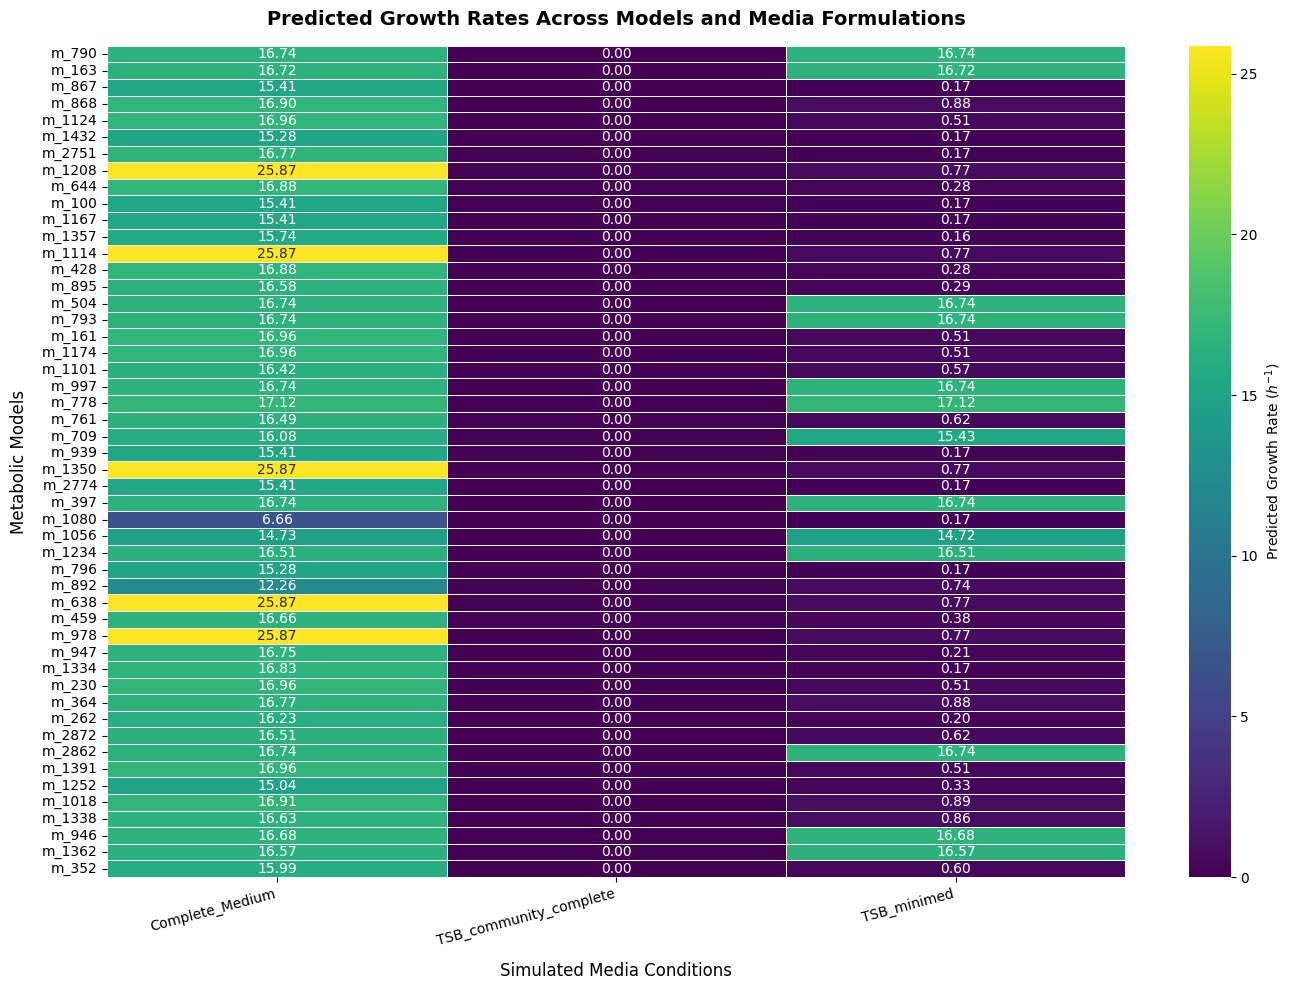

In [48]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_filtered,
    #df_filtered.iloc[:,[0, 5]],
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# sve TSB complete medium 
save_media(completed_media["TSB_completed"], "TSB_completed")

,0
EX_glc__D_e,10.0
EX_na1_e,10.0
EX_cl_e,10.0
EX_k_e,10.0
EX_pi_e,10.0
...,...
EX_ddca_e,10.0
EX_ttdcea_e,10.0
EX_pser__L_e,10.0
EX_tyr__D_e,10.0


### compare the different media on their own 

In [19]:
all_media_comps = defaultdict(list)

for media_id, medium in mediadict.items():
    for ex_r in medium.keys():
        all_media_comps[ex_r].append(media_id)

#### what do they share?

In [ ]:
medium = {"AF7": set(AF7.keys()), "AF8": set(AF8.keys()), "Root7" : set(Root7.keys()), "Root8" : set(Root8.keys())}
venn(medium)

Text(0.5, 0, 'Amount medium components')

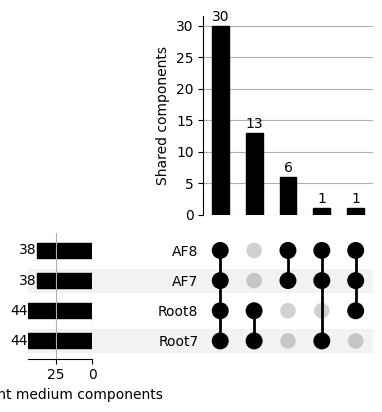

In [77]:
data = from_contents(medium)
upset = UpSet(data, show_counts=True, sort_by='cardinality')
axes = upset.plot()

# Y-axis of main plot
axes['intersections'].set_ylabel("Shared components")

# X-axis of totals
axes['totals'].set_xlabel("Amount medium components")


#### compare metabolite classes in media

In [36]:
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

In [37]:
as_d, count_d = assign_metaboliteclass_medium(AF7, met_class_dict)

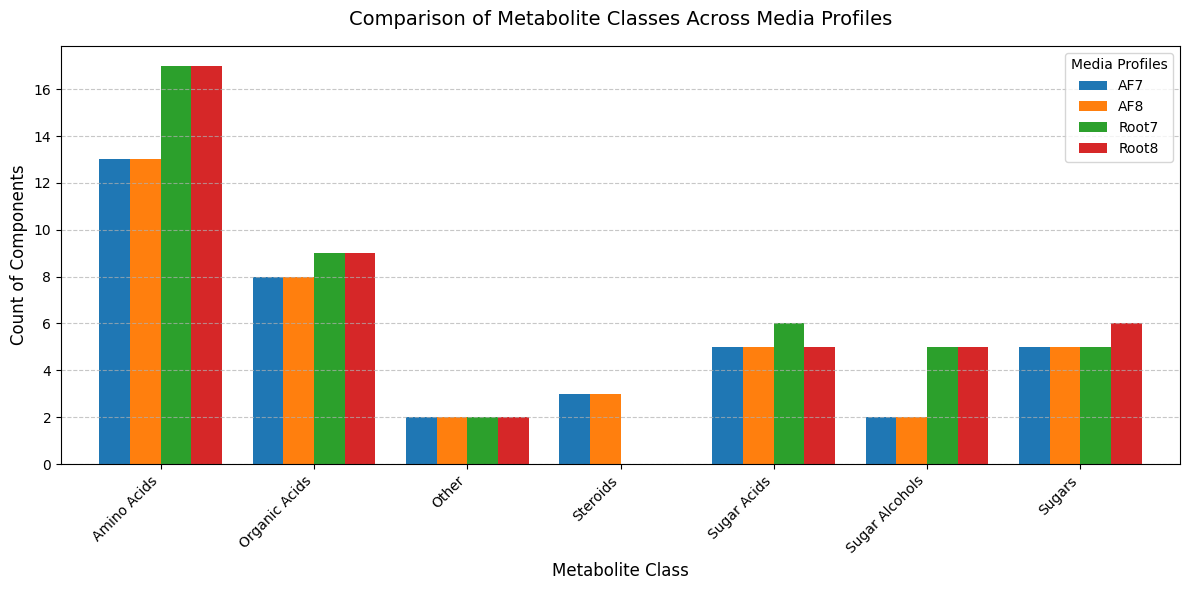

In [46]:
all_media_counts = {}

for med_id, medium in mediadict.items():
    as_d, c_d = assign_metaboliteclass_medium(medium, met_class_dict)
    all_media_counts[med_id] = c_d


df_counts = pd.DataFrame(all_media_counts).fillna(0)
df_counts = df_counts.sort_index()
ax = df_counts.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title("Comparison of Metabolite Classes Across Media Profiles", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()

## Community playground

In [5]:
from micom import load_pickle
from micom.media import complete_medium, minimal_medium


In [6]:
def compute_medium_series(csv_medium):
    new_id = csv_medium.copy()
    new_id[0] = new_id[0].astype(str).str.strip().str.replace(r'\d+$', '', regex=True)
    new_id[0] = new_id[0].str.replace('_e', '_m')
    flux_values = pd.to_numeric(new_id[1], errors='coerce').fillna(1000.0)
    med_series = pd.Series(flux_values.values, index=new_id[0].astype(str).str.strip())
    med_series = med_series[med_series.index.notna() & (med_series.index != 'nan')]
    return med_series

In [7]:
c1 = load_pickle("/home/emma/Dokumente/thesis/communities/HvSC1.pickle")
c2 = load_pickle("/home/emma/Dokumente/thesis/communities/HvSC2.pickle")

In [8]:
min_com_growth = 0.1
min_indi_growth = 0.01

In [9]:
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"), header = None)
AF7_s = compute_medium_series(AF7)

In [140]:
HvSC1_af7 = complete_medium(HvSC1, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)
HvSC2_af7= complete_medium(c2, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/02/26 11:09:39] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=192837;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=319629;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

[07/02/26 11:09:50] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=615740;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=381627;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [141]:
min_med_sc1 = minimal_medium(HvSC1, 0.1, minimize_components = True)

[07/02/26 11:09:52] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=194129;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=18403;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [158]:
min_med_sc2 = minimal_medium(HvSC2, 0.1, minimize_components = True)

[07/02/26 11:22:00] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=254736;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=201123;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [162]:
len(min_med_sc2)

44

In [159]:
min_med_sc1_l = set(min_med_sc1.index)
min_med_sc2_l = set(min_med_sc2.index)

In [143]:
af7_l = set(AF7_s.index)

In [152]:
tsb_m = []
for reac in TSB[0]:
    clean = reac[:-2]
    clean_m = clean + "_m"
    tsb_m.append(clean_m)

In [153]:
intersect_sc1 = min_med_sc1_l.intersection(tsb_m)
only_af7_1 = af7_l - min_med_sc1_l
only_min1 = min_med_sc1_l - af7_l

##### venn visualization

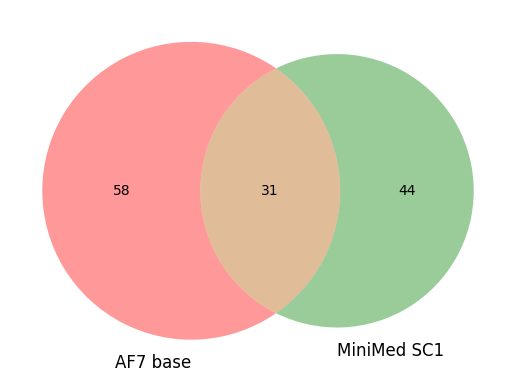

In [155]:
venn2(subsets=(len(af7_l), len(min_med_sc1_l), len(intersect_sc1)), set_labels=('AF7 base', 'MiniMed SC1'))

In [160]:
intersect_sc2 = min_med_sc2_l.intersection(tsb_m)
only_af7_2 = af7_l - min_med_sc2_l
only_min2 = min_med_sc2_l - af7_l

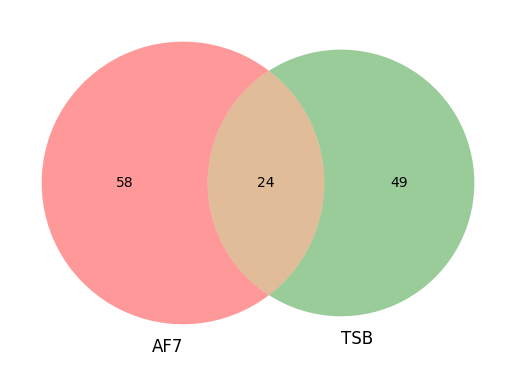

In [ ]:
venn2(subsets=(len(af7_l), len(tsb_m), len(set(tsb_m).intersection(af7_l))), set_labels=('AF7', 'TSB'))

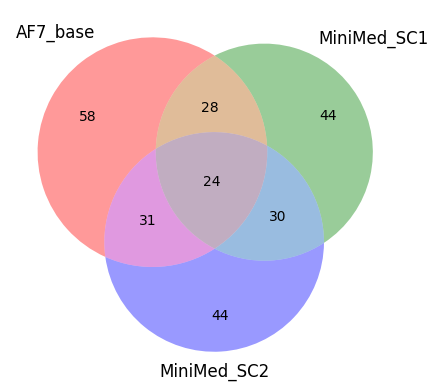

In [163]:
venn3(subsets=(len(af7_l), len(min_med_sc2_l), len(intersect_sc2), len(min_med_sc1_l), len(intersect_sc1), len(min_med_sc1_l.intersection(min_med_sc2_l)), len(set(intersect_sc1).intersection(intersect_sc2))), set_labels=('AF7_base', "MiniMed_SC1", 'MiniMed_SC2'))

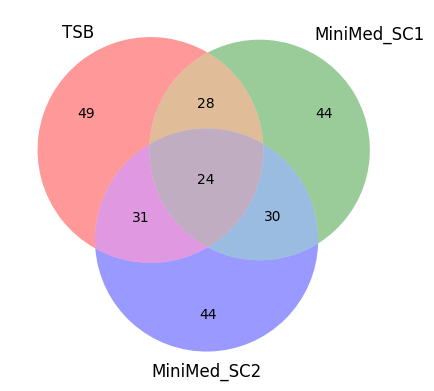

In [ ]:
venn3(subsets=(len(af), len(min_med_sc2_l), len(intersect_sc2), len(min_med_sc1_l), len(intersect_sc1), len(min_med_sc1_l.intersection(min_med_sc2_l)), len(set(intersect_sc1).intersection(intersect_sc2))), set_labels=('TSB', "MiniMed_SC1", 'MiniMed_SC2'))

##### what does each strain need?

In [ ]:
minimal_medium = {}
min_med_growth_rates = {}
for file in os.listdir(model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    #print(model_id)
    mini_med = cobra.medium.minimal_medium(model, 1.0, exports = True, minimize_components=True)
    minimal_medium[model_id] = mini_med

    if mini_med is not None:
        default_medium = model.medium.copy()
        try:
            model.medium = mini_med.to_dict() 
            growth_rate = model.slim_optimize()
            min_med_growth_rates[model_id] = growth_rate if not np.isnan(growth_rate) else 0.0
        except Exception as e:
            print(f"Error calculating growth on minimal medium for {model_id}: {e}")
            min_med_growth_rates[model_id] = 0.0
        finally:
            model.medium = default_medium  
    else:
        # If no minimal medium was found, growth rate is 0.0
        min_med_growth_rates[model_id] = 0.0

        
# list of all EX_reactions from minimal_media
count_mods_per_reaction = defaultdict(list)

for model_id, medium in minimal_medium.items():
    if medium is None:
        print(f"Skipping {model_id} because no minimal medium could be found.")
        continue
    for ex_r, flux in medium.items():
        if flux > 0:
            count_mods_per_reaction[ex_r].append(model_id)


Error calculating growth on minimal medium for m_2774: The lower bound must be less than or equal to the upper bound (1000.0000000000001 <= 1000.0).
Error calculating growth on minimal medium for m_709: The lower bound must be less than or equal to the upper bound (1000.0000000000002 <= 1000.0).
Error calculating growth on minimal medium for m_1167: The lower bound must be less than or equal to the upper bound (1000.0000000000001 <= 1000.0).


In [ ]:
# figure out which ex_r are missing in the predefined media
onlyin2 = list()
ex_r_missinginmedia = defaultdict(list)
for ex_r, counts in count_mods_per_reaction.items():
    if len(counts) < 2:
        onlyin2.append(ex_r)

EX_pser__L_e
EX_ddca_e
EX_octscoa_e
EX_glyb_e
EX_so4_e
EX_ala_gln_e
EX_nh4_e
EX_fald_e
EX_lys__D_e
EX_dgsn_e
EX_3gmp_e
EX_gly_met_e
EX_rnam_e
EX_balabala_e
EX_ins_e
EX_so3_e
EX_dhap_e
EX_orn_e
EX_co2_e
EX_xtsn_e
EX_citr__L_e
EX_gly_asp__L_e
EX_thymd_e


##### define own minimal medium function 

In [13]:
from cobra.flux_analysis import flux_variability_analysis

In [14]:
min_growth = 0.1


In [105]:
c1_x = read_sbml_model("/home/emma/Dokumente/thesis/communities/HvSC1.xml")
c2_x = read_sbml_model("/home/emma/Dokumente/thesis/communities/HvSC2.xml")

No objective coefficients in model. Unclear what should be optimized
No objective coefficients in model. Unclear what should be optimized


In [ ]:
c1_x.reactions.

Name,HvSC1
Memory address,757542a4f4c0
Number of metabolites,7313
Number of reactions,7419
Number of genes,7
Number of groups,0
Objective expression,1.0*Growth__m_100 - 1.0*Growth__m_100_reverse_c8b70 + 1.0*Growth__m_1018 -...
Compartments,"e__m_1174, c__m_1174, p__m_1174, extracellular, e__m_1234, c__m_1234, p__m_1234, e__m_1334, c__m_1334, p__m_1334, e__m_100, c__m_100, p__m_100, e__m_161, c__m_161, p__m_161, e__m_163, c__m_163, p__m_163, e__m_230, c__m_230, p__m_230, e__m_352, c__m_352, p__m_352, e__m_364, c__m_364, p__m_364, e__m_504, c__m_504, p__m_504, e__m_644, c__m_644, p__m_644, e__m_761, c__m_761, p__m_761, e__m_778, c__m_778, p__m_778, e__m_793, c__m_793, p__m_793, e__m_867, c__m_867, p__m_867, e__m_868, c__m_868, p__m_868, e__m_892, c__m_892, p__m_892, e__m_946, c__m_946, p__m_946, e__m_1018, c__m_1018, p__m_1018, e__m_1056, c__m_1056, p__m_1056, e__m_1124, c__m_1124, p__m_1124, e__m_1167, c__m_1167, p__m_1167, e__m_1391, c__m_1391, p__m_1391, e__m_1432, c__m_1432, p__m_1432, e__m_2774, c__m_2774, p__m_2774, e__m_2862, c__m_2862, p__m_2862, e__m_2872, p__m_2872, c__m_2872"


In [106]:
c1_exr = []
biomass_c1 = {}
for reac in c1_x.reactions:
    if "Growth" in reac.id:
        biomass_c1[reac] = 1.0
        reac.bounds = (1/27, 1000)
    if "EX" in reac.id:
        c1_exr.append(reac)

In [107]:
c1_x.objective = biomass_c1

In [108]:
c1_x.slim_optimize()

85.31489404668245

In [19]:
c1_fva = flux_variability_analysis(c1_x, c1_exr)

In [20]:
rows = {}
for ex_r in c1_fva.index:
    current_min = c1_fva.loc[ex_r, 'minimum']
    current_max = c1_fva.loc[ex_r, 'maximum']
    
    # Split from the right side at the double underscore exactly once
    # "EX_LalaDgluMdap_e__m_1174" becomes ["EX_LalaDgluMdap_e", "m_1174"]
    clean_id = ex_r.rsplit("__", 1)[0]
    
    if clean_id not in rows:
        rows[clean_id] = [current_min, current_max]
    else:
        if current_min < rows[clean_id][0]:
            rows[clean_id][0] = current_min
        if current_max > rows[clean_id][1]:
            rows[clean_id][1] = current_max

rows = [[id_key, values[0], values[1]] for id_key, values in rows.items()]
sum_fva_c1 = pd.DataFrame(rows, columns=["exchange_reaction", "min_value", "max_value"])
sum_fva_c1 = sum_fva_c1[sum_fva_c1["max_value"] < 0]

In [22]:
c1_essential = cobra.flux_analysis.variability.find_essential_reactions(c1_x, threshold=0.1, processes=2)

In [23]:
c1_essential_ids = {rxn.id if hasattr(rxn, 'id') else rxn for rxn in c1_essential}
c1_essential_exr  = [rxn for rxn in c1_essential_ids if "EX" in rxn]

In [24]:
c1_essential_exr_sum = []
for ex_r in c1_essential_exr:    
    split_id = ex_r.split("_")
    clean_id = split_id[0] + "_" + split_id[1] + "_" + split_id[2]
    if clean_id not in c1_essential_exr_sum:
        c1_essential_exr_sum.append(clean_id)

In [26]:
c1_essential_imports = []

for ex_r in c1_essential_exr_sum:
    if ex_r in sum_fva_c1["exchange_reaction"].values:
        if "_m" in ex_r and "_e" not in ex_r:
            c1_essential_imports.append(ex_r)

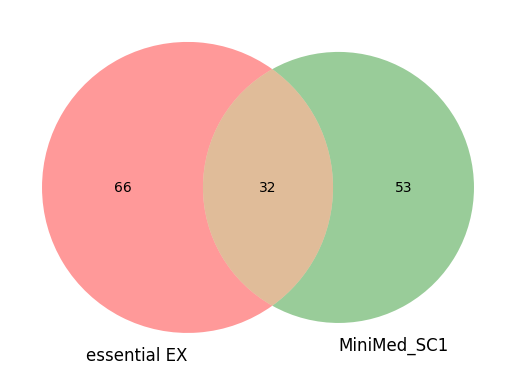

In [45]:
venn2(subsets = (len(c1_essential_imports), len(min_med_sc1_l), len(set(c1_essential_imports).intersection(min_med_sc1_l))), set_labels = ('essential EX', 'MiniMed_SC1'))

In [111]:
# reasign essential imports as medium and see how the stuff grows 
essential_imports_medium = {ex_r: 1000 for ex_r in c1_essential_imports}
medium_ = get_model_specific_medium(c1_x, essential_imports_medium)
c1_x.medium = medium_

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


In [114]:
len(c1_x.medium)

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


66

In [112]:
c1_x.optimize()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


<Solution infeasible at 0x75756d44df60>

In [46]:
set(c1_essential_imports).intersection(min_med_sc1_l)

{'EX_6pgc_m',
 'EX_LalaDgluMdap_m',
 'EX_acmana_m',
 'EX_acnam_m',
 'EX_alaala_m',
 'EX_amp_m',
 'EX_bz_m',
 'EX_ca2_m',
 'EX_cl_m',
 'EX_cmp_m',
 'EX_cobalt2_m',
 'EX_cu2_m',
 'EX_dtmp_m',
 'EX_fe2_m',
 'EX_fol_m',
 'EX_glyc3p_m',
 'EX_glyglygln_m',
 'EX_gmp_m',
 'EX_hdca_m',
 'EX_k_m',
 'EX_meoh_m',
 'EX_mg2_m',
 'EX_mn2_m',
 'EX_nmn_m',
 'EX_o2_m',
 'EX_pheme_m',
 'EX_prohisglu_m',
 'EX_ribflv_m',
 'EX_sheme_m',
 'EX_tton_m',
 'EX_xtsn_m',
 'EX_zn2_m'}

In [47]:
min_med_sc1_l - set(c1_essential_imports)

{'EX_R_3httdca_m',
 'EX_acac_m',
 'EX_akg_m',
 'EX_ala__L_m',
 'EX_arg__L_m',
 'EX_asn__L_m',
 'EX_asp__L_m',
 'EX_coa_m',
 'EX_gln__L_m',
 'EX_ile__L_m',
 'EX_leu__L_m',
 'EX_lys__L_m',
 'EX_mal__L_m',
 'EX_met__L_m',
 'EX_phe__L_m',
 'EX_pro__L_m',
 'EX_ser__L_m',
 'EX_thr__L_m',
 'EX_trp__L_m',
 'EX_tyr__L_m',
 'EX_val__L_m'}

In [109]:
true_minimal_med = cobra.medium.minimal_medium(c1_x, minimize_components=True)

functional_medium_dict = true_minimal_med.to_dict()
c1_x.medium = functional_medium_dict
solution = c1_x.optimize()
print( solution.objective_value)

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
The MIP version of minimal media is extremely slow for models that large :(
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


1.0000000000000118


# complete AF7 media 

In [131]:
from micom import Community

In [129]:
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

##### define communities

In [130]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_ex.xml")

In [132]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [156]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_ex.xml")

In [157]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

##### complete medium

In [124]:
min_com_growth = 0.1
min_indi_growth = 0.01

In [125]:
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"), header = None)
AF7_s = compute_medium_series(AF7)

In [187]:
af_c1

EX_LalaDgluMdap_m     0.004245
EX_R_3httdca_m        0.006100
EX_acmana_m           0.008882
EX_acnam_m            0.000060
EX_ala__L_m          10.000000
                       ...    
EX_cytd_m             0.001591
EX_ncam_m             0.000002
EX_octscoa_m          0.000058
EX_tton_m             0.155707
EX_pser__L_m          0.008521
Length: 83, dtype: float64

In [138]:
af_c1 = complete_medium(HvSC1, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/02/26 11:09:06] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=341454;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=696007;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [168]:
af_c2 = complete_medium(HvSC2, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/02/26 12:14:31] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=318092;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=166160;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

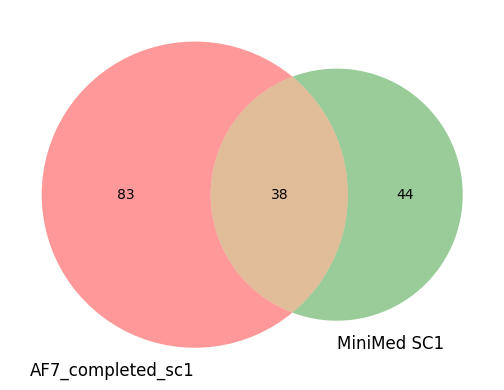

In [186]:
venn2(subsets=(len(af_c1), len(min_med_sc1_l), len(af_c1.index.intersection(min_med_sc1_l))), set_labels=('AF7_completed_sc1', 'MiniMed SC1'))

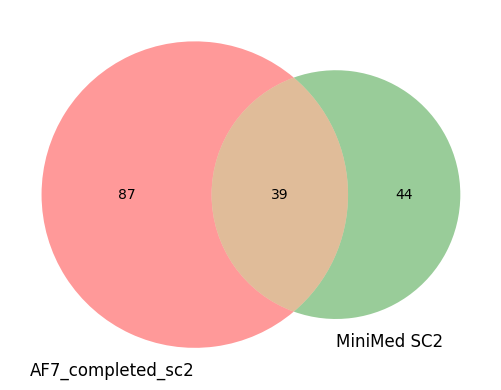

In [185]:
venn2(subsets=(len(af_c2), len(min_med_sc2_l), len(af_c2.index.intersection(min_med_sc2_l))), set_labels=('AF7_completed_sc2', 'MiniMed SC2'))

In [ ]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_ex.xml")

In [170]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

In [177]:
b  = (af_c2.index).intersection(min_med_sc2_l)

In [174]:
set(af_c2.index) - min_med_sc2_l

{'EX_3ump_m',
 'EX_6pgc_m',
 'EX_LalaDgluMdap_m',
 'EX_R_3httdca_m',
 'EX_acmana_m',
 'EX_acnam_m',
 'EX_adn_m',
 'EX_ala__L_m',
 'EX_amp_m',
 'EX_asp__L_m',
 'EX_balabala_m',
 'EX_chor_m',
 'EX_cit_m',
 'EX_citr__L_m',
 'EX_cmp_m',
 'EX_cytd_m',
 'EX_dad_2_m',
 'EX_ddca_m',
 'EX_fe3_m',
 'EX_for_m',
 'EX_fum_m',
 'EX_g3pg_m',
 'EX_glc__D_m',
 'EX_glu__L_m',
 'EX_gly_m',
 'EX_glyc3p_m',
 'EX_glyc_m',
 'EX_gmp_m',
 'EX_h2o_m',
 'EX_h_m',
 'EX_hdca_m',
 'EX_icit_m',
 'EX_mal__L_m',
 'EX_met__L_m',
 'EX_mmet_m',
 'EX_na1_m',
 'EX_nac_m',
 'EX_nh4_m',
 'EX_no3_m',
 'EX_peng_m',
 'EX_pep_m',
 'EX_pheme_m',
 'EX_pi_m',
 'EX_sheme_m',
 'EX_so4_m',
 'EX_succ_m',
 'EX_ttdca_m',
 'EX_uri_m'}

In [179]:
a = set(af_c1.index).intersection(min_med_sc1_l)


In [175]:
set(af_c1.index) - min_med_sc1_l

{'EX_3ump_m',
 'EX_R_3httdca_m',
 'EX_acmana_m',
 'EX_acnam_m',
 'EX_ala_L_thr__L_m',
 'EX_alaala_m',
 'EX_argp_m',
 'EX_bz_m',
 'EX_cmp_m',
 'EX_cytd_m',
 'EX_dgsn_m',
 'EX_fe3_m',
 'EX_for_m',
 'EX_fum_m',
 'EX_g3pg_m',
 'EX_glc__D_m',
 'EX_glu__L_m',
 'EX_glyc3p_m',
 'EX_h2o_m',
 'EX_h_m',
 'EX_hdca_m',
 'EX_icit_m',
 'EX_mal__L_m',
 'EX_meoh_m',
 'EX_mevR_m',
 'EX_na1_m',
 'EX_ncam_m',
 'EX_nh4_m',
 'EX_nmn_m',
 'EX_no3_m',
 'EX_octscoa_m',
 'EX_peng_m',
 'EX_phe__L_m',
 'EX_pheme_m',
 'EX_pi_m',
 'EX_pser__L_m',
 'EX_pydam_m',
 'EX_pydx_m',
 'EX_sheme_m',
 'EX_succ_m',
 'EX_ttdca_m',
 'EX_tyr__L_m',
 'EX_uaccg_m',
 'EX_uri_m',
 'EX_xtsn_m'}

In [182]:
helper_d = {"AF7_complete_sc1" : set(af_c1.index), "AF7_complete_sc2": set(af_c2.index), "MinMed_sc1": min_med_sc1_l, "MinMed_sc2": min_med_sc2_l}

<Axes: >

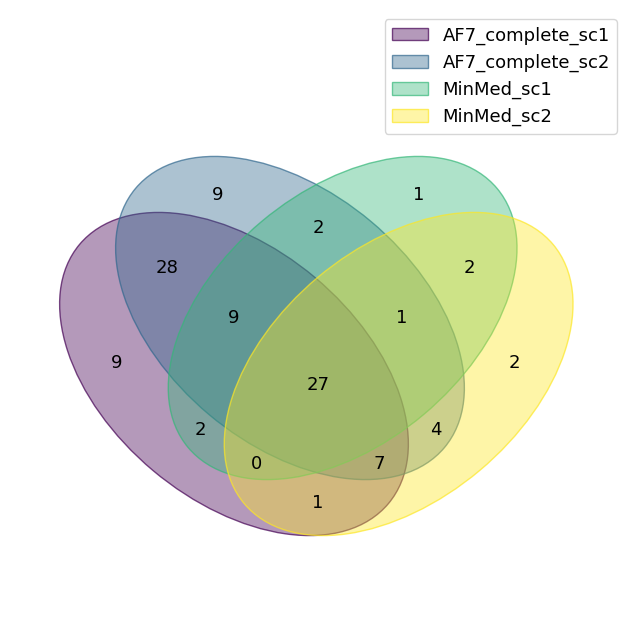

In [183]:
venn(helper_d)

In [189]:
# combine both media, if ex_r is present in both media, take the higher flux
combined_afmedium = af_c1
for ex_r, flux in af_c2.items():
    if ex_r not in combined_afmedium.keys():
        combined_afmedium[ex_r] = flux
    if ex_r in combined_afmedium.keys():
        if combined_afmedium[ex_r] < flux:
            combined_afmedium[ex_r] = flux

In [195]:
save_media(combined_afmedium.to_dict(), "combined_af", media_dir)

,0
EX_LalaDgluMdap_m,0.004245
EX_R_3httdca_m,0.006100
EX_acmana_m,0.008882
EX_acnam_m,0.000293
EX_ala__L_m,10.000000
...,...
EX_so4_m,1000.000000
EX_citr__L_m,0.023511
EX_adn_m,0.011847
EX_ddca_m,0.000014


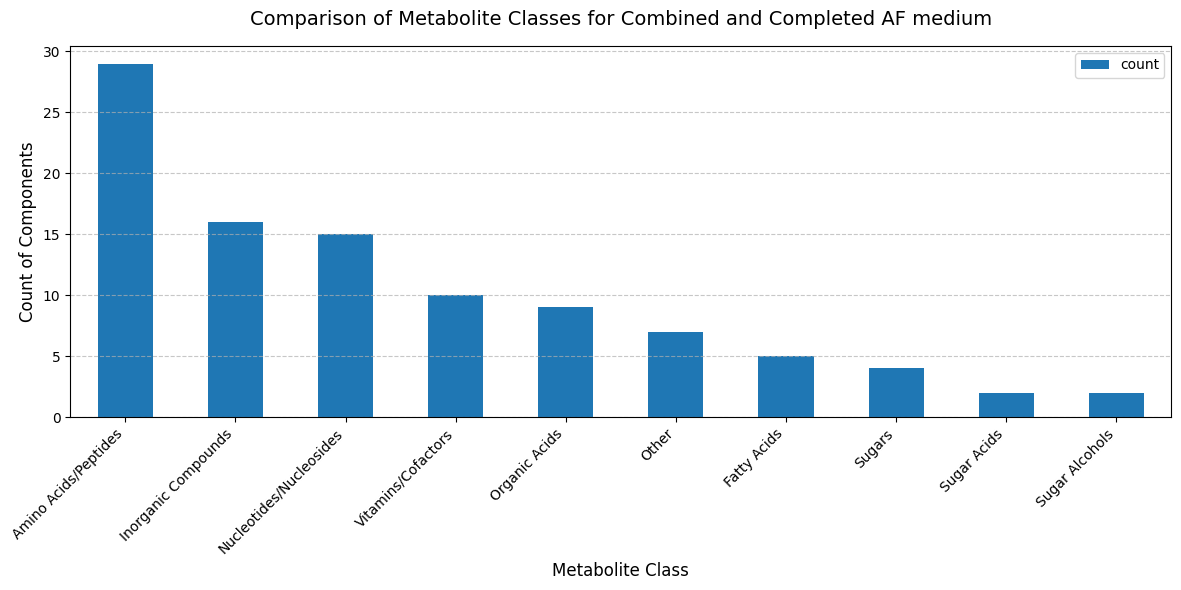

In [231]:
### analyze combined medium 
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

as_d, c_d = assign_metaboliteclass_medium(combined_afmedium, met_class_dict)

df_counts = df_counts.drop([0, 1], errors='ignore')
df_counts = pd.Series(c_d).to_frame(name = "count")
df_counts = df_counts.sort_values(by="count", ascending=False)
ax = df_counts.plot(kind='bar', figsize=(12, 6))

plt.title("Comparison of Metabolite Classes for Combined and Completed AF medium", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()

In [223]:
df_counts

,0
Amino Acids/Peptides,29
Fatty Acids,5
Sugars,4
Sugar Acids,2
Nucleotides/Nucleosides,15
Organic Acids,9
Inorganic Compounds,16
Vitamins/Cofactors,10
Sugar Alcohols,2
Other,7


In [225]:
df_counts.sort_values(by="count")

,count
Sugar Acids,2
Sugar Alcohols,2
Sugars,4
Fatty Acids,5
Other,7
Organic Acids,9
Vitamins/Cofactors,10
Nucleotides/Nucleosides,15
Inorganic Compounds,16
Amino Acids/Peptides,29
